In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py

In [2]:
problem_size = 10**2

In [3]:
grid_len = int(np.sqrt(problem_size))

nx, ny, nz = grid_len, grid_len, 3
Lx=512e3
Ly=Lx
dx = Lx/(nx-1)
dy = dx

f0=1.4e-4
gravity=9.81
Ho=1000
accuracy='float64'
x = (np.arange(nx,dtype = accuracy)+0.5)*dx;
y = (np.arange(ny,dtype = accuracy)+0.5)*dy;
xx,yy = np.meshgrid(x,y);
xu,yu = np.meshgrid(x-.5*dx,y);
xv,yv = np.meshgrid(x,y-.5*dy);

# Flat bottom at z=-Ho
h=-Ho*np.ones((ny,nx),dtype = accuracy);
# channnel walls
h[:,-1]=0;
h[-1,:]=0;

variableWindField = True
shiftWindField = True
if variableWindField:
# variable wind field
    period = 16 # days
    if shiftWindField: period = 4 # days
    writeFreq = 3 # hours
    t = np.arange(0,period*24/writeFreq)/(24./writeFreq) # time in days
    vmax = 15.0; # maximale windgeschwindigkeit in m/s

    if shiftWindField:
        t = t + 4
        mx = Lx*.1 + Lx*.1*t
        my = Ly*.1 + Ly*.1*t
    else:
        tP=np.mod(t,period/2)
        tP[t>=period/2.]=period/2.-tP[t>=period/2.]
        tP = tP/(0.5*period)
        oLx=150.e3
        oLy=oLx
        mx = -oLx+(2*oLx+Lx)*tP
        my = -oLy+(2*oLy+Ly)*tP

    alpha0= np.pi/2. - np.pi/2./5. # 90 grad ist ohne Konvergenz oder Divergenz
    alpha = np.pi/2. - np.pi/2./5.*np.maximum(np.sign(np.roll(mx,-1)-mx),0.) \
            -np.pi/2./10.*np.maximum(np.sign(mx-np.roll(mx,-1)),0.)

    uwind = np.zeros((t.shape[0],xx.shape[0],xx.shape[1]))
    vwind = np.zeros((t.shape[0],yy.shape[0],yy.shape[1]))
    for k,myt in enumerate(t):
        wx =  np.cos(alpha[k])*(xx-mx[k]) + np.sin(alpha[k])*(yy-my[k])
        wy = -np.sin(alpha[k])*(xx-mx[k]) + np.cos(alpha[k])*(yy-my[k])
        r = np.sqrt((mx[k]-xx)*(mx[k]-xx)+(my[k]-yy)*(my[k]-yy))
        s = 1.0/50.e3*np.exp(-r/100.e3)
        if shiftWindField:
            w = np.tanh(myt*(8.0-myt)/2.)
        else:
            if myt<8:
                w = np.tanh(myt*(period/2.-myt)/2.)
            elif myt>=8 and myt<16:
                w = -np.tanh((myt-period/2.)*(period-myt)/2.)
        #    w = np.sin(2.0*np.pi*myt/period)

        # reset scaling factor w to one
        w = 1.
        uwind[k,:,:] = -wx*s*w*vmax;
        vwind[k,:,:] = -wy*s*w*vmax;

        spd=np.sqrt(uwind[k,:,:]**2+vwind[k,:,:]**2)
        div=uwind[k,1:-1,2:]-uwind[k,1:-1,:-2] \
             +vwind[k,2:,1:-1]-vwind[k,:-2,1:-1]

# ocean
uo = +0.01*(2*yy-Ly)/Ly
vo = -0.01*(2*xx-Lx)/Lx

# initial thickness:
hice = 0.3 + 0.005*np.sin(500*xx) + 0.005*np.sin(500*yy)
# symmetrize
hices = 0.5*(hice + hice.transpose())
# initial thickness with random noise
hice = 0.3 + np.random.normal(scale=0.003,size=xx.shape)
# initial thickness for comparison with:
hice = 0.3 + 0.005*(np.sin(60./1000.e3*xx) + np.sin(30./1000.e3*yy))

In [4]:
def fill_overlap(A):
        A[:2, :] = A[-4:-2, :]
        A[-2:, :] = A[2:4, :]
        A[:, :2] = A[:, -4:-2]
        A[:, -2:] = A[:, 2:4]

        return A

grid_len = int(np.sqrt(problem_size))
ones2d = np.ones((grid_len+4,grid_len+4))

def create(val):
    return ones2d * val

def createfrom(field):
    field_full_size = ones2d * 1
    field_full_size[2:-2,2:-2] = field
    field_full_size = fill_overlap(field_full_size)
    return field_full_size

hIceMean  = createfrom(hice)
#hIceMean  = create(0.3)
hSnowMean = create(0)
Area      = create(1)
TSurf     = create(273.0)

uWind  = createfrom(uwind[0,:,:]) * 0
vWind  = createfrom(vwind[0,:,:]) * 0

maskInC = create(1)
maskInC[-3,:] = 0
maskInC[:,-3] = 0
maskInU = maskInC * np.roll(maskInC,5,axis=1)
maskInV = maskInC * np.roll(maskInC,5,axis=0)

maskInC = fill_overlap(maskInC)
maskInU = fill_overlap(maskInU)
maskInV = fill_overlap(maskInV)

uOcean = createfrom(uo) * maskInU
vOcean = createfrom(vo) * maskInV

R_low = createfrom(h)

fcormin = 0.00014604
fcormax = 0.00015388
y = np.linspace(fcormin, fcormax, grid_len)
y = y[:,np.newaxis] * np.ones((grid_len,grid_len))
fCori = createfrom(y)
fCori = create(0)

iceMask, iceMaskU, iceMaskV  = maskInC*1, maskInU*1, maskInV*1

deltaX = create(8000)
dxC, dyC, dxG, dyG, dxU, dyU, dxV, dyV = [deltaX*1 for _ in range(8)]
recip_dxC, recip_dyC, recip_dxG, recip_dyG, recip_dxU, recip_dyU, recip_dxV, recip_dyV = [1 / deltaX for _ in range(8)]

rA  = dxU * dyV
rAz = dxV * dyU
rAu = dxC * dyG
rAv = dxG * dyC
recip_rA = 1 / rA
recip_rAz = 1 / rAz
recip_rAu = 1 / rAu
recip_rAv = 1 / rAv

fields = [
    hIceMean, hSnowMean, Area, TSurf, uOcean, vOcean, uWind, vWind, R_low,
    maskInC, maskInU, maskInV, iceMask, iceMaskU, iceMaskV, fCori,
    dxC, dyC, dxG, dyG, dxU, dyU, dxV, dyV,
    recip_dxC, recip_dyC, recip_dxG, recip_dyG, recip_dxU, recip_dyU, recip_dxV, recip_dyV,
    rA, rAz, rAu, rAv, recip_rA, recip_rAz, recip_rAu, recip_rAv
    ]

def namestr(obj, namespace):
    return [name for name in namespace if namespace[name] is obj][0]

names = [namestr(var, globals()) for var in fields]

init_fields = {name: field for name, field in zip(names, fields)}

with h5py.File('initial_fields.h5', 'w') as file:

    for name, field in zip(names, fields):
        file.create_dataset(name, data=field)

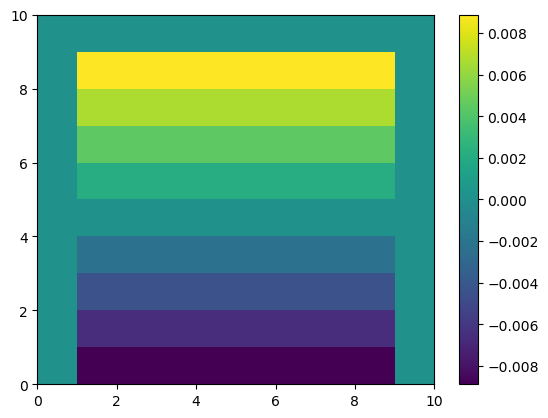

In [6]:
plt.pcolormesh(uOcean[2:-2,2:-2])
plt.colorbar()